In [16]:
from src.data.data import *
from src.embedor import *
from src.plotting import *
import pandas as pd
import matplotlib
import seaborn as sns
import argparse
import umap
import numpy as np
from sklearn.manifold import TSNE, Isomap, SpectralEmbedding
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

import phate
%load_ext autoreload

output_dir = 'figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_dir = os.path.join(output_dir, 'subsample_test')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

n_points = 5000
subsample_factors = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
np.random.seed(42)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def est_geodesic_distance(X, k=15, scale_factor=1):
    """
    Estimate the geodesic distance using the knn graph.
    :param k: number of neighbors
    :return: geodesic distance matrix. Note: infinite values get snapped to a scaled version of the max finite value
    """
    knn = kneighbors_graph(X, n_neighbors=k, mode='distance', include_self=False)
    knn = knn.toarray()
    knn[knn == 0] = np.inf
    # knn[knn > 0] = 1
    dists = shortest_path(knn, method='D', directed=False)
    # max finite value
    max_dist = np.nanmax(dists[~np.isinf(dists)])
    dists[np.isinf(dists)] = max_dist * scale_factor
    return dists


In [ ]:
# circles
%autoreload 2
from src.data.data import *
noise = 0.1
noise_thresh = None
return_dict = concentric_circles(n_points=n_points, factor=0.4, noise=noise, noise_thresh=noise_thresh)
gt_geodesic_distance = est_geodesic_distance(return_dict['noiseless_data'], k=15)

spearman_corrs_circles = []
for subsample_factor in subsample_factors:
    embedor = EmbedOR(subsample=True, subsample_factor=subsample_factor)
    embedding = embedor.fit_transform(return_dict['data'])
    pdist_embedor = squareform(pdist(embedding, metric='euclidean'))
    spearman_corr_embedor, _ = spearmanr(pdist_embedor.flatten(), gt_geodesic_distance.flatten())
    print(f'Spearman correlation EmbedOR: {spearman_corr_embedor}')
    spearman_corrs_circles.append(spearman_corr_embedor)


In [11]:
noise = 1
noise_thresh = None
return_dict = swiss_roll(n_points=n_points, noise=noise, noise_thresh=noise_thresh)
gt_geodesic_distance = est_geodesic_distance(return_dict['noiseless_data'], k=15)

spearman_corrs_swiss_roll = []
for subsample_factor in subsample_factors:
    embedor = EmbedOR(subsample=True, subsample_factor=subsample_factor)
    embedding = embedor.fit_transform(return_dict['data'])
    pdist_embedor = squareform(pdist(embedding, metric='euclidean'))
    spearman_corr_embedor, _ = spearmanr(pdist_embedor.flatten(), gt_geodesic_distance.flatten())
    print(f'Spearman correlation EmbedOR: {spearman_corr_embedor}')
    spearman_corrs_swiss_roll.append(spearman_corr_embedor)


Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
All indices shape: (2, 12497500)
subsample indices shape: (2, 11252285)
0.9003628725745149
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.9322018075629456
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
All indices shape: (2, 12497500)
subsample indices shape: (2, 10007104)
0.8007284656931386
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.9253363671156555
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
All indices shape: (2, 12497500)
subsample indices shape: (2, 8761776)
0.7010822964592919
Initializing embedding...
Running Stochastic Neighbor Embedding...


In [12]:
noise = 0.5
noise_thresh = None
return_dict = torus(n_points=n_points, noise=noise, noise_thresh=noise_thresh, double=True)
gt_geodesic_distance = est_geodesic_distance(return_dict['noiseless_data'], k=15)

spearman_corrs_torus = []
for subsample_factor in subsample_factors:
    embedor = EmbedOR(subsample=True, subsample_factor=subsample_factor)
    embedding = embedor.fit_transform(return_dict['data'])
    pdist_embedor = squareform(pdist(embedding, metric='euclidean'))
    spearman_corr_embedor, _ = spearmanr(pdist_embedor.flatten(), gt_geodesic_distance.flatten())
    print(f'Spearman correlation EmbedOR: {spearman_corr_embedor}')
    spearman_corrs_torus.append(spearman_corr_embedor)

Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.8225204850816491
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.818381735117189
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.8129700635685363
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman corre

In [13]:
noisy_tree, tree = gen_dla(n_dim=100, n_branch=8, sigma=4, branch_length=500)
return_dict = {'data': noisy_tree, 'noiseless_data': tree}
gt_geodesic_distance = est_geodesic_distance(return_dict['noiseless_data'], k=15)

spearman_corrs_tree = []
for subsample_factor in subsample_factors:
    embedor = EmbedOR(subsample=True, subsample_factor=subsample_factor)
    embedding = embedor.fit_transform(return_dict['data'])
    pdist_embedor = squareform(pdist(embedding, metric='euclidean'))
    spearman_corr_embedor, _ = spearmanr(pdist_embedor.flatten(), gt_geodesic_distance.flatten())
    print(f'Spearman correlation EmbedOR: {spearman_corr_embedor}')
    spearman_corrs_tree.append(spearman_corr_embedor)

Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.6317029778145088
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.7009693838463552
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman correlation EmbedOR: 0.7295730120686539
Building nearest neighbor graph...
Computing distances...
Computing affinities...
Updating the graph attributes...
Subsampling interactions...
Initializing embedding...
Running Stochastic Neighbor Embedding...
Spearman corr

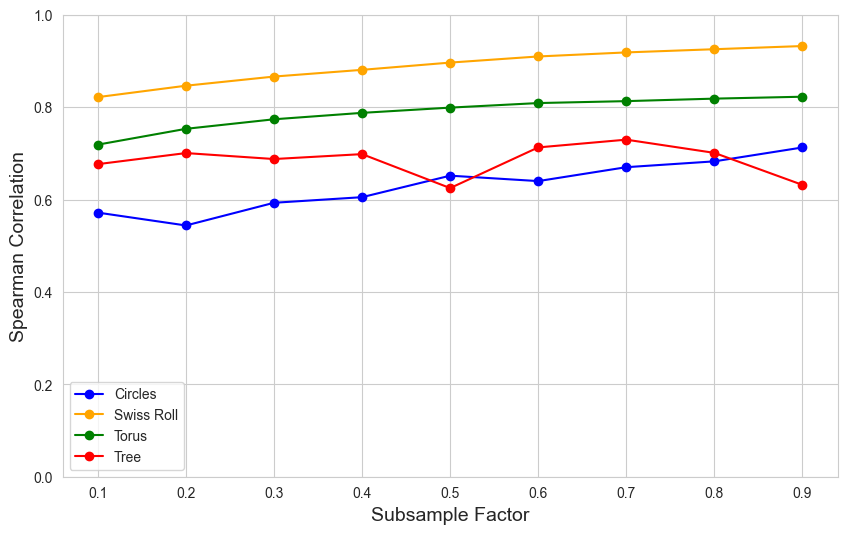

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(subsample_factors, spearman_corrs_circles, label='Circles', color='blue', marker='o')
plt.plot(subsample_factors, spearman_corrs_swiss_roll, label='Swiss Roll', color='orange', marker='o')
plt.plot(subsample_factors, spearman_corrs_torus, label='Torus', color='green', marker='o')
plt.plot(subsample_factors, spearman_corrs_tree, label='Tree', color='red', marker='o')
plt.xlabel('Subsample Factor', fontsize=14)
plt.ylabel('Spearman Correlation', fontsize=14)
plt.ylim(0, 1)
plt.legend()
plt.savefig(os.path.join(output_dir, 'subsample_spearman_correlations.png'), dpi=1200)